This Jupyter notebook demonstrates the usage of the utils API wrapper layer. It’s self-contained and can be run via Restart & Run All. Make sure utils.py is in the same directory and that you’ve installed dependencies (requests, pandas, matplotlib).

### 1. Setup and Imports

In [1]:
# Standard imports
import os
import requests
import pandas as pd
import utils as api
from dotenv import load_dotenv

# Display plots inline
%matplotlib inline

#Load from .env file
load_dotenv()

# Load Demo Plan API key (set as environment variable or replace here)
API_KEY = os.getenv('API_KEY')

### 2. Fetching Current Price

In [2]:
# Fetch Bitcoin price in USD
df_price = api.fetch_price(
    coin_id='bitcoin',
    vs_currencies='usd'
)

df_price.head()

,price
timestamp,
2025-04-30 01:44:56.442043+00:00,94538


### 3. Computing a Moving Average

In [3]:
# Compute 20-period moving average on the fetched price series
df_ma = api.compute_moving_average(
    coin_id='bitcoin',
    vs_currency='usd',
    window=20,
    api_key=API_KEY
)

df_ma.head()

,price,ma_20
timestamp,,
2025-04-29 02:01:26.787000+00:00,95037.684270,95037.684270
2025-04-29 03:04:53.530000+00:00,94634.347753,94836.016011
2025-04-29 04:04:55.231000+00:00,94711.855826,94794.629283
2025-04-29 05:04:53.801000+00:00,94402.847589,94696.683859
2025-04-29 06:05:22.025000+00:00,94309.341506,94619.215389


### 4. Plotting Price Trend with Moving Average

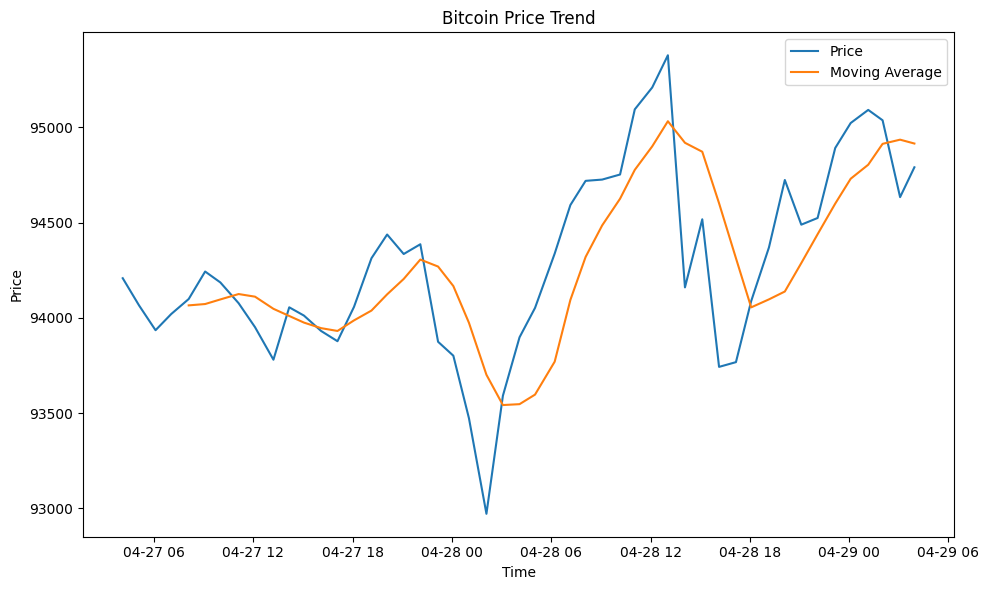

In [23]:
endpoint = 'https://api.coingecko.com/api/v3/coins/bitcoin/market_chart'
params = {
    'vs_currency': 'usd',
    'days': 2, 
}

resp = requests.get(endpoint, params=params)
resp.raise_for_status()
history = resp.json()['prices']  # list of [timestamp_ms, price]

# Convert to DataFrame and normalize timestamp
df_hist = pd.DataFrame(history, columns=['timestamp_ms', 'price'])
df_hist['timestamp'] = pd.to_datetime(df_hist['timestamp_ms'], unit='ms')
df_hist = df_hist.set_index('timestamp').drop(columns='timestamp_ms')

# Compute a 5-point moving average on historical data
df_hist_ma = api.compute_moving_average(df_hist, window=5)

# Plot the historical trend and MA
api.plot_price_trend(
    df_hist_ma,
    price_col='price',
    ma_col='ma_5'
)

### 5. Fetching Full Market Data
This function is optional and it is used for showing some of the elements that are present in coingecko api

In [24]:
# Retrieve comprehensive market metrics

df_market = api.fetch_market_data(
    coin_id='bitcoin',
    vs_currency='usd',
    api_key=API_KEY
)

# Show key columns
df_market.loc[:, [
    'current_price', 'market_cap', 'total_volume',
    'high_24h', 'low_24h', 'price_change_percentage_24h'
]]

,current_price,market_cap,total_volume,high_24h,low_24h,price_change_percentage_24h
0,94784,1882126451243,30330201614,95491,93589,0.98878
